# Parameter Estimation and Calibration

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Cofi import style
%matplotlib inline
style.apply()
FONT_SIZE = style.FONT_SIZE
DATA, FIG = "data", "figures"
os.makedirs(FIG, exist_ok=True)
pd.set_option("display.width", 160)
qnum = lambda q: int("".join(c for c in q if c.isdigit()) or 0)

G = pd.read_csv(f"{DATA}/s3-grid.csv")
M = json.load(open(f"{DATA}/minio.json"))
TP = pd.read_csv(f"{DATA}/task-profile.csv").set_index("operator")
META = json.load(open(f"{DATA}/task-profile-meta.json"))
b1, bmax, g = M["B1_MBps"], M["Bmax_MBps"], M["gamma"]
agg = lambda k: np.minimum(k * b1, bmax / (1 + g * k))
k_star = (-1 + np.sqrt(1 + 4 * g * bmax / b1)) / (2 * g)

GN = pd.read_csv(f"{DATA}/nfs-grid.csv")
MN = json.load(open(f"{DATA}/nfs.json"))
b1n, bmaxn, gn = MN["B1_MBps"], MN["Bmax_MBps"], MN["gamma"]
agg_nfs = lambda k: np.minimum(k * b1n, bmaxn / (1 + gn * k))
k_star_nfs = (-1 + np.sqrt(1 + 4 * gn * bmaxn / b1n)) / (2 * gn) if gn > 0 else bmaxn / b1n

print(f"B1 = {b1:.0f} MB/s, Bmax = {bmax:.0f} MB/s, gamma = {g:.3f}, k* = {k_star:.1f}, peak = {agg(k_star) / 1024:.2f} GB/s, "
      f"error aggregate {M['mape_agg_%']:.0f}% / per function {M['mape_fn_%']:.0f}%")
print(f"NFS: B1 = {b1n:.0f} MB/s, Bmax = {bmaxn:.0f} MB/s, gamma = {gn:.3f}, k* = {k_star_nfs:.1f}, peak = {agg_nfs(k_star_nfs) / 1024:.2f} GB/s, "
      f"error aggregate {MN['mape_agg_%']:.0f}% / per function {MN['mape_fn_%']:.0f}%")


B1 = 234 MB/s, Bmax = 2403 MB/s, gamma = 0.013, k* = 9.2, peak = 2.10 GB/s, error aggregate 4% / per function 9%
NFS: B1 = 74 MB/s, Bmax = 781 MB/s, gamma = 0.000, k* = 10.5, peak = 0.76 GB/s, error aggregate 6% / per function 8%


## MinIO system

In [2]:
G["billed_read_s"] = G["p"] * G["t_read"]
t = G.pivot_table(index="size", columns="mp", values="wall").round(2)
b = G.pivot_table(index="size", columns="mp", values="billed_read_s").round(0)
print("Lineitem scan wall time (s): rows = max_size_mb, columns = max_parallel"); display(t)
print("Billed read time = functions × read time (s)"); display(b)

Lineitem scan wall time (s): rows = max_size_mb, columns = max_parallel


mp,10,20,30,50,70,100
size,,,,,,
5,9.30,7.05,6.56,7.05,7.13,6.97
30,9.37,6.83,7.27,6.79,6.97,7.03
50,7.41,6.33,6.46,7.08,7.76,7.05
65,7.04,6.36,6.73,8.01,8.01,8.44
70,6.91,6.24,7.03,8.11,8.64,8.92
90,6.87,6.45,7.20,8.19,9.95,8.20
110,6.74,6.27,7.06,8.27,9.08,12.23
130,6.64,6.19,6.80,8.51,10.83,7.69
155,6.41,7.45,6.93,8.44,10.86,11.40


Billed read time = functions × read time (s)


mp,10,20,30,50,70,100
size,,,,,,
5,57.0,94.0,140.0,306.0,382.0,381.0
30,56.0,88.0,186.0,235.0,362.0,391.0
50,48.0,90.0,147.0,219.0,407.0,255.0
65,48.0,92.0,149.0,323.0,409.0,435.0
70,46.0,90.0,170.0,323.0,408.0,407.0
90,47.0,91.0,171.0,322.0,457.0,233.0
110,51.0,101.0,187.0,367.0,483.0,481.0
130,50.0,101.0,180.0,358.0,509.0,299.0
155,47.0,117.0,172.0,317.0,548.0,518.0


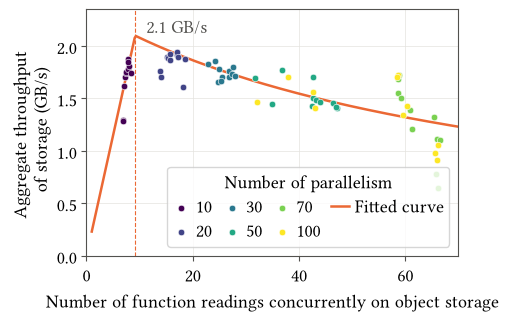

In [3]:
# This code draw a chart
FIGSIZE, XMAX, YMAX = (4.8, 3.2), 70, 2.35
MODEL = "#eb6834"
mps = sorted(G["mp"].unique())
cmap = plt.get_cmap("viridis", len(mps))
fig, ax = plt.subplots(figsize=FIGSIZE)
for i, mp in enumerate(mps):
    R = G[G.mp == mp]
    ax.scatter(R["readers"], R["agg_MBps"] / 1024, s=22, color=cmap(i), edgecolor="white", lw=0.4, zorder=3, label=f"{int(mp)}")

k = np.linspace(1, XMAX, 300)
ax.plot(k, agg(k) / 1024, color=MODEL, lw=1.8, zorder=2, label="Fitted curve")
ax.axvline(k_star, color=MODEL, lw=0.8, ls="--", zorder=1)
ax.annotate(f"{agg(k_star) / 1024:.1f} GB/s", (k_star, agg(k_star) / 1024), xytext=(8, 2), textcoords="offset points", color=style.INK2, fontsize=FONT_SIZE)
ax.set_xlim(0, XMAX); ax.set_ylim(0, YMAX)
ax.set_xlabel("Number of function readings concurrently on object storage")
ax.set_ylabel("Aggregate throughput \n of storage (GB/s)")
ax.grid(True, color=style.GRID); ax.set_axisbelow(True)
ax.legend(title="Number of parallelism", title_fontsize=FONT_SIZE, fontsize=FONT_SIZE, frameon=True, ncol=4, loc="lower right", borderpad=0.3, labelspacing=0.2, handlelength=1.0, handletextpad=0.3, columnspacing=0.6)

style.save(fig, FIG, "minio-g5k-agg")
plt.show()

## Network file system (NFS)

In [4]:
# This code draw a chart
GN["billed_read_s"] = GN["p"] * GN["t_read"]
t = GN.pivot_table(index="size", columns="mp", values="wall").round(2)
b = GN.pivot_table(index="size", columns="mp", values="billed_read_s").round(0)
print("NFS read stage wall time (s): rows = max_size_mb, columns = max_parallel"); display(t)
print("Billed read time = functions × read time (s)"); display(b)

NFS read stage wall time (s): rows = max_size_mb, columns = max_parallel


mp,10,20,30,50,70,100
size,,,,,,
10,8.55,8.29,7.81,7.64,7.00,6.43
20,8.11,9.20,7.73,7.74,6.65,7.31
30,9.00,8.55,8.41,7.98,7.33,6.63
40,7.85,8.17,7.86,7.10,7.18,6.44
50,8.02,7.84,7.77,7.51,7.04,6.02
60,7.87,7.35,8.04,7.24,7.13,6.38
80,8.02,8.59,7.92,6.78,6.16,7.31
100,8.22,7.68,7.22,7.55,5.96,7.04
130,7.50,7.58,7.92,7.53,6.68,7.31


Billed read time = functions × read time (s)


mp,10,20,30,50,70,100
size,,,,,,
10,82.0,159.0,221.0,333.0,414.0,386.0
20,73.0,168.0,209.0,345.0,358.0,407.0
30,86.0,160.0,235.0,328.0,430.0,367.0
40,75.0,160.0,219.0,297.0,405.0,352.0
50,77.0,152.0,220.0,334.0,400.0,356.0
60,75.0,138.0,231.0,336.0,384.0,342.0
80,78.0,162.0,221.0,277.0,391.0,446.0
100,79.0,148.0,195.0,336.0,338.0,396.0
130,71.0,149.0,221.0,345.0,288.0,325.0


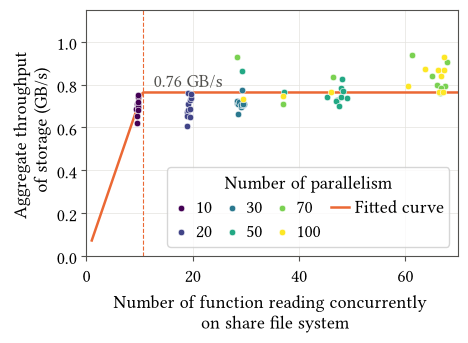

In [5]:
FIGSIZE, XMAX, YMAX = (4.8, 3.2), 70, 1.15
mps = sorted(GN["mp"].unique())
cmap = plt.get_cmap("viridis", len(mps))
fig, ax = plt.subplots(figsize=FIGSIZE)
for i, mp in enumerate(mps):
    R = GN[GN.mp == mp]
    ax.scatter(R["readers"], R["agg_MBps"] / 1024, s=22, color=cmap(i), edgecolor="white", lw=0.4, zorder=3, label=f"{int(mp)}")

k = np.linspace(1, XMAX, 300)
ax.plot(k, agg_nfs(k) / 1024, color=MODEL, lw=1.8, zorder=2, label="Fitted curve")
ax.axvline(k_star_nfs, color=MODEL, lw=0.8, ls="--", zorder=1)
ax.annotate(f"{agg_nfs(k_star_nfs) / 1024:.2f} GB/s", (k_star_nfs, agg_nfs(k_star_nfs) / 1024), xytext=(8, 4), textcoords="offset points", color=style.INK2, fontsize=FONT_SIZE)
ax.set_xlim(0, XMAX); ax.set_ylim(0, YMAX)

ax.set_xlabel("Number of function reading concurrently \n on share file system")
ax.set_ylabel("Aggregate throughput \n of storage (GB/s)")
ax.grid(True, color=style.GRID); ax.set_axisbelow(True)

ax.legend(title="Number of parallelism", title_fontsize=FONT_SIZE, fontsize=FONT_SIZE, frameon=True, ncol=4, loc="lower right", borderpad=0.3, labelspacing=0.2, handlelength=1.0, handletextpad=0.3, columnspacing=0.6)

style.save(fig, FIG, "nfs-g5k-agg")
plt.show()


## MinIO and NFS side by side

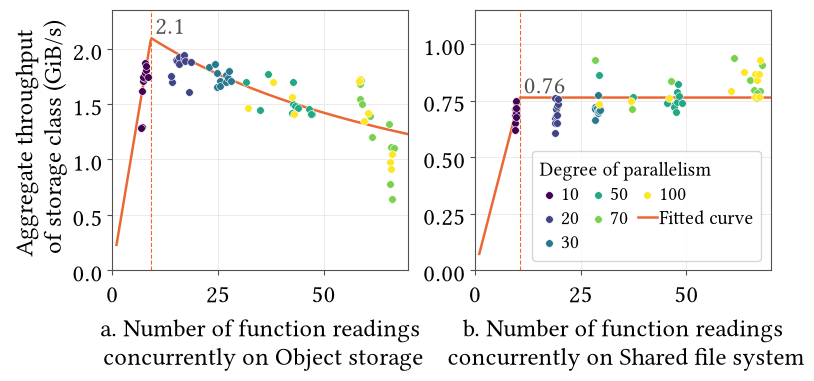

In [6]:
PANELS = [("(a) MinIO (S3 object storage)", G, agg, k_star, 2.35, "{:.1f}", "Object storage"),
          ("(b) NFS (shared file system)", GN, agg_nfs, k_star_nfs, 1.15, "{:.2f}", "Shared file system")
          ]
XMAX = 70
FS = FONT_SIZE + 5
mps = sorted(set(G["mp"]) | set(GN["mp"]))
cmap = plt.get_cmap("viridis", len(mps))
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (title, D, f, ks, ymax, fmt, where) in zip(axes, PANELS):
    for i, mp in enumerate(mps):
        R = D[D.mp == mp]
        ax.scatter(R["readers"], R["agg_MBps"] / 1024, s=30, color=cmap(i), edgecolor="white", lw=0.4, zorder=3, label=f"{int(mp)}")

    k = np.linspace(1, XMAX, 300)
    ax.plot(k, f(k) / 1024, color=MODEL, lw=1.8, zorder=2, label="Fitted curve")
    ax.axvline(ks, color=MODEL, lw=0.8, ls="--", zorder=1)
    ax.annotate(f"{fmt.format(f(ks) / 1024)}", (ks, f(ks) / 1024), xytext=(3, 3), textcoords="offset points", color=style.INK2, fontsize=FS)
    ax.set_xlim(0, XMAX); ax.set_ylim(0, ymax)

    if where == 'Object storage':
        ax.set_xlabel(f"a. Number of function readings\n concurrently on {where}", fontsize=FS)
    else:
        ax.set_xlabel(f"b. Number of function readings\n concurrently on {where}", fontsize=FS)
    ax.tick_params(labelsize=FS)

    ax.grid(True, color=style.GRID); ax.set_axisbelow(True)

axes[0].set_ylabel("Aggregate throughput \n of storage class (GiB/s)", fontsize=FS)
h, l = axes[0].get_legend_handles_labels()

fig.legend(h, l, title="Degree of parallelism",  alignment='left', ncol=3, title_fontsize=FS - 4,
           fontsize=FS -4, frameon=True, loc="lower center", bbox_to_anchor=(0.82, 0.3),
           handlelength=1, handletextpad=0.1, columnspacing=0.5, labelspacing=0.1, borderpad=0.4)

fig.tight_layout(w_pad=1.5)
style.save(fig, FIG, "storage-g5k-agg")
plt.show()


## System parameters

In [7]:
SP = pd.read_csv(f"{DATA}/system-params.csv")

def fmt_value(v):
    if v == 0:
        return "0"
    if abs(v) < 1e-3 or abs(v) >= 1e6:
        m, e = f"{v:.3e}".split("e")
        return f"{float(m):g}e{int(e)}"
    return f"{v:,.0f}" if float(v).is_integer() else f"{v:.4g}"


SP["value"] = SP["value"].map(fmt_value)
display(SP.set_index(["category", "parameter"])[["symbol", "value", "unit"]].fillna(""))

symbol     value             unit
category                parameter                                                                          
Function                vCPU per function                                      c         2             vCPU
                        Memory per function                                          2,048              MiB
                        Requests per instance                                            1          request
                        Function timeout                                               300                s
                        Minimum instances                                               30         instance
                        Maximum instances                                               70         instance
Runner                  Functions running at once per stage         max_parallel        70         function
                        Default partition size                       max_size_mb        50               MB
                        Reader threads per scan function             max_workers         4           thread
                        Retries per task                                                 3            retry
                        Rows per task (limit)                                        4.5e7              row
Storage (MinIO, fitted) Read bandwidth of one function alone                  B1     234.1             MB/s
                        Peak aggregate read bandwidth                       Bmax      2403             MB/s
                        Slowdown per concurrent reader                     gamma     0.013       1/function
Model (calibrated)      S3 bandwidth                                       bw_s3       147             MB/s
                        S3 slowdown per concurrent function              beta_s3    0.2744            ms/MB
                        NFS bandwidth                                     bw_nfs     784.1             MB/s
                        NFS latency                                      lat_nfs    0.9428       ms/request
                        Dispatch time                                 kappa_disp     46.56      ms/function
                        Scan processing rate                           kappa_cpu       256    MB/s per vCPU
                        Join processing rate                           kappa_cpu     117.8    MB/s per vCPU
                        Aggregate processing rate                      kappa_cpu     29.46    MB/s per vCPU
                        Join slowdown per concurrent function           beta_cpu    0.1508            ms/MB
                        Aggregate slowdown per concurrent function      beta_cpu    0.1547            ms/MB
                        Aggregate request latency                     kappa_qlat      0.59       ms/request
Model (fixed)           Bloom-filter hashing rate                         r_hash       5e7  hash/s per vCPU
Price                   Invocation                                                    2e-7     $/invocation
                        Compute                                                   1.667e-5           $/GB-s
                        S3 GET                                                        4e-7        $/request
                        S3 PUT                                                        5e-6        $/request
                        S3 storage                                                   0.023       $/GB-month
                        NFS storage                                                    0.3       $/GB-month

## Calibrated platform parameters κ


In [8]:
K = json.load(open(f"{DATA}/kappa-v5.json"))
rows = {"κ^bw S3 (MB/s)": [k["bw"]["s3"] / 1e6 for k in K.values()],
        "κ^lat S3 (ms)": [k["lat"]["s3"] * 1e3 for k in K.values()],
        "κ^bw NFS (MB/s)": [k["bw"]["nfs"] / 1e6 for k in K.values()],
        "κ^lat NFS (ms)": [k["lat"]["nfs"] * 1e3 for k in K.values()],
        "κ^disp (ms)": [k["disp"] * 1e3 for k in K.values()],
        "β S3 (ms per MB per concurrent function)": [k["beta"].get("s3", 0) * 2**20 * 1e3 for k in K.values()]}

for e in sorted({e for k in K.values() for e in k["rate"]}):
    rows[f"κ^cpu {e} (MB/s per vCPU)"] = [k["rate"][e] / 1e6 if k["rate"][e] < 1e14 else np.inf for k in K.values() if e in k["rate"]]

pd.DataFrame({n: {"median": np.median(v), "min": np.min(v), "max": np.max(v)} for n, v in rows.items()}).T.style.format("{:.2f}")

,median,min,max
κ^bw S3 (MB/s),230.72,200.24,252.78
κ^lat S3 (ms),0.00,0.00,0.00
κ^bw NFS (MB/s),843.76,843.61,919.66
κ^lat NFS (ms),0.95,0.92,1.28
κ^disp (ms),52.29,43.51,54.46
β S3 (ms per MB per concurrent function),0.33,0.31,0.34
κ^cpu /aggregate@nfs (MB/s per vCPU),38.22,32.46,62.13
κ^cpu /aggregate@s3 (MB/s per vCPU),34.58,32.28,41.07
κ^cpu /join@nfs (MB/s per vCPU),inf,431.15,inf
κ^cpu /join@s3 (MB/s per vCPU),55.75,42.46,72.32
